<a href="https://colab.research.google.com/github/karlwoww/gan_mnist_fashion/blob/main/gan_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as op

op.download("https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kuznecept
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database


100%|██████████| 778M/778M [00:02<00:00, 350MB/s]


In [ ]:
import tensorflow as tf                                                               # библиотека Tensorflow
import keras                                                                          # библиотека Keras
from keras.layers import Input, Conv2D, MaxPooling2D, Activation, ReLU, Rescaling     # cлои библиотеки Keras
from keras.layers import BatchNormalization, Conv2DTranspose, Concatenate             # cлои библиотеки Keras
from keras.layers import Rescaling, Resizing                                          # cлои библиотеки Keras
from keras.models import Model, Sequential                                            # конструкторы построения моделей библиотеки Keras

from keras.optimizers import Adam                                                     # оптимизатор Adam
from keras.preprocessing.image import  load_img                                       # загрузка изображений
from keras.utils import to_categorical                                                # преобразует вектор класса (целые числа) в двоичную матрицу класса

from keras.callbacks import EarlyStopping, ModelCheckpoint

import cv2                                                                   # генератор случайных чисел

import numpy as np                                                                    # библиотека линейной алгебры
import pandas as pd                                                                   # библиотека обработки табличных данных
import os                                                                             # библиотека работы с функциями операционной системы, в том числе с файлами
import albumentations as A                                                            # библиотека аугментации изображений (https://albumentations.ai/)

import matplotlib.pyplot as plt                                                       # библиотека для рисования графиков
%matplotlib inline

In [ ]:
path_imag = './covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images'
path_mask = './covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks'

In [ ]:
imag = [f'{path_imag}/{i}' for i in os.listdir(path_imag)]
mask = [f'{path_mask}/{i}' for i in os.listdir(path_mask)]

In [ ]:
class DatasetGenerator(keras.utils.Sequence):
    def __init__(self, images, masks, batch_size=8, img_size=(256,256), num_classes=2):
        self.images = images
        self.masks = masks
        self.batch_size = batch_size
        self.img_size = img_size
        self.num_classes = num_classes

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, index):
        start = index * self.batch_size
        end = start + self.batch_size

        X = []
        Y = []

        for i in range(start, end):
            # Загружаем снимок (без изменений)
            img = cv2.imread(self.images[i], cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, self.img_size)
            img = img / 255.0
            img = img.reshape(*self.img_size, 1)

            # Загружаем маску
            mask = cv2.imread(self.masks[i], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)
            mask = mask / 255.0

            # ПРЕОБРАЗУЕМ В ONE-HOT (2 класса)
            mask_one_hot = to_categorical(mask, num_classes=self.num_classes)

            X.append(img)
            Y.append(mask_one_hot)

        return np.array(X), np.array(Y)


In [ ]:
val_samples = 500

# Расщепим наш датасет  на обучающую и проверочные выборки
train_input_img_path = imag[:-val_samples]
train_target_img_path = mask[:-val_samples]
val_input_img_path = imag[-val_samples:]
val_target_img_path = mask[-val_samples:]

In [ ]:
train_gen = DatasetGenerator(train_input_img_path, train_target_img_path)

val_gen = DatasetGenerator(val_input_img_path, val_target_img_path)

In [ ]:
IMG_SIZE = 256
num_classes = 2

In [ ]:
def convolution_operation(entered_input, filters=64):
    conv1 = Conv2D(filters, kernel_size=(3,3), padding="same")(entered_input)
    batch_norm1 = BatchNormalization()(conv1)
    acti1 = ReLU()(batch_norm1)

    conv2 = Conv2D(filters, kernel_size=(3,3), padding="same")(acti1)
    batch_norm2 = BatchNormalization()(conv2)
    acti2 = ReLU()(batch_norm2)

    return acti2

def encoder(entered_input, filters=64):
    encod1 = convolution_operation(entered_input, filters)
    MaxPool1 = MaxPooling2D(strides=(2,2))(encod1)
    return encod1, MaxPool1

def decoder(entered_input, skip, filters=64):
    Upsample = Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(entered_input)
    Connect_Skip = Concatenate()([Upsample, skip])
    out = convolution_operation(Connect_Skip, filters)
    return out

def U_Net(img_size, num_classes=2):  # num_classes=2 по умолчанию
    inputs = Input(img_size)

    skip1, encoder_1 = encoder(inputs, 64)
    skip2, encoder_2 = encoder(encoder_1, 128)  # 64*2 = 128
    skip3, encoder_3 = encoder(encoder_2, 256)  # 64*4 = 256
    skip4, encoder_4 = encoder(encoder_3, 512)  # 64*8 = 512

    conv_block = convolution_operation(encoder_4, 1024)  # 64*16 = 1024


    decoder_1 = decoder(conv_block, skip4, 512)  # 64*8 = 512
    decoder_2 = decoder(decoder_1, skip3, 256)  # 64*4 = 256
    decoder_3 = decoder(decoder_2, skip2, 128)  # 64*2 = 128
    decoder_4 = decoder(decoder_3, skip1, 64)   # 64


    outputs = Conv2D(num_classes, kernel_size=(1, 1), padding="same", activation="softmax")(decoder_4)

    model = Model(inputs, outputs)
    return model

In [ ]:
model = U_Net((IMG_SIZE, IMG_SIZE, 1), num_classes=2)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,210 (118.46 MB)

 Trainable params: 31,042,434 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:
callbacks = [
    ModelCheckpoint("segmentation.keras", monitor='val_loss', save_best_only=True),
]

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
epochs = 3
history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=epochs,
                    batch_size=8,
                    callbacks=callbacks
                   )

Epoch 1/3
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 659s 544ms/step - accuracy: 0.9967 - loss: 0.0080 - val_accuracy: 0.9968 - val_loss: 0.0077
Epoch 2/3
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 659s 544ms/step - accuracy: 0.9970 - loss: 0.0069 - val_accuracy: 0.9970 - val_loss: 0.0070
Epoch 3/3
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 652s 539ms/step - accuracy: 0.9971 - loss: 0.0066 - val_accuracy: 0.9969 - val_loss: 0.0075


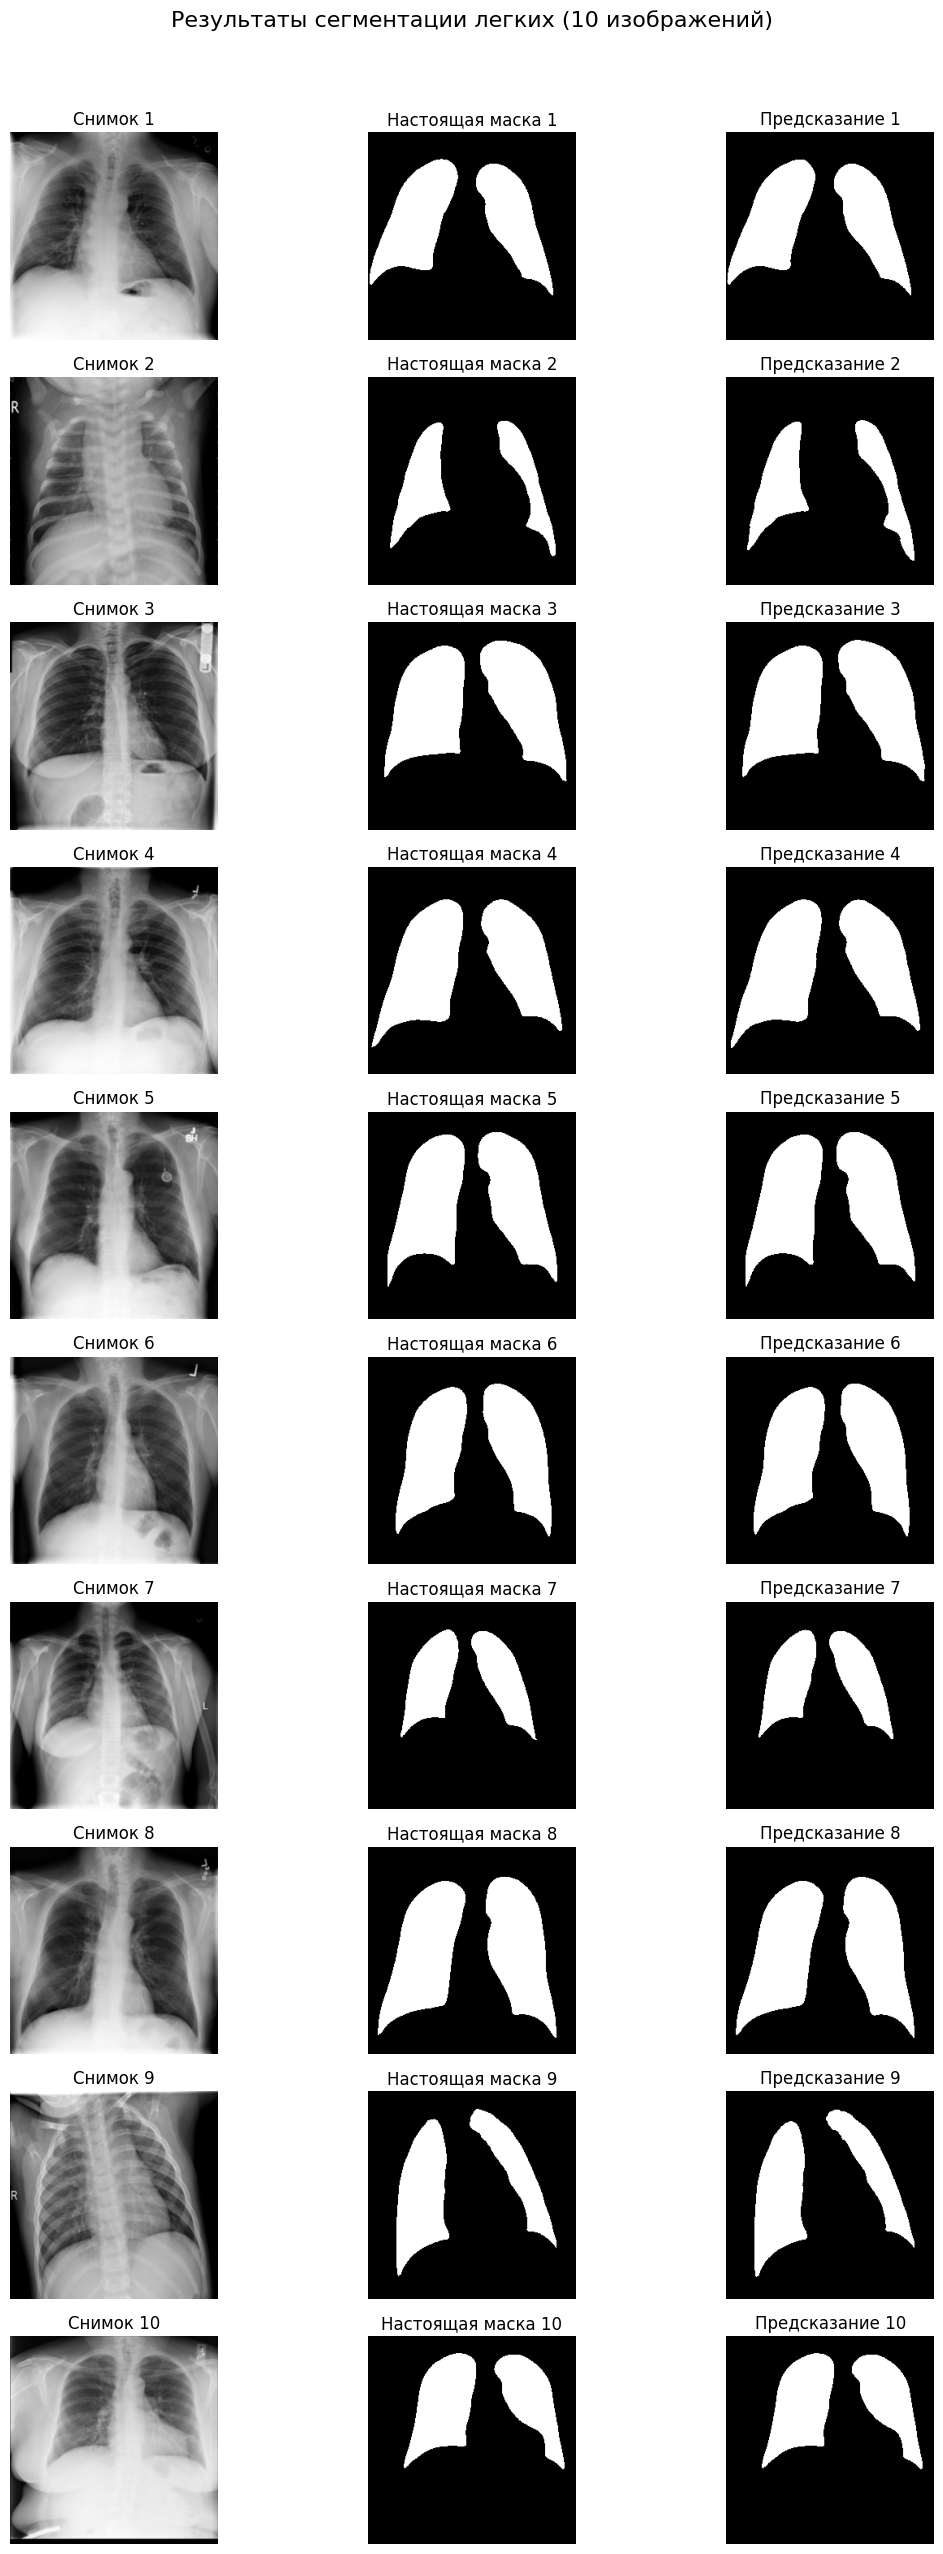

In [ ]:
def show_predictions(model, generator):
    x_batch1, y_batch1 = generator[0]
    x_batch2, y_batch2 = generator[1]

    x_all = np.concatenate([x_batch1, x_batch2])
    y_all = np.concatenate([y_batch1, y_batch2])

    x_10 = x_all[:10]
    y_10 = y_all[:10]

    pred_10 = model.predict(x_10, verbose=0)


    true_masks = np.argmax(y_10, axis=-1)
    pred_masks = np.argmax(pred_10, axis=-1)

    fig, axes = plt.subplots(10, 3, figsize=(12, 25))

    for i in range(10):
        # Оригинал
        axes[i, 0].imshow(x_10[i].squeeze(), cmap='gray')
        axes[i, 0].set_title(f'Снимок {i+1}')
        axes[i, 0].axis('off')

        # Настоящая маска
        axes[i, 1].imshow(true_masks[i], cmap='gray')
        axes[i, 1].set_title(f'Настоящая маска {i+1}')
        axes[i, 1].axis('off')

        # Предсказание
        axes[i, 2].imshow(pred_masks[i], cmap='gray')
        axes[i, 2].set_title(f'Предсказание {i+1}')
        axes[i, 2].axis('off')

    plt.suptitle('Результаты сегментации легких (10 изображений)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


show_predictions(model, val_gen)